<a href="https://colab.research.google.com/github/nollamae7-spec/DSRSP-Solar-Flares/blob/main/DSHRP_Solar_Flares.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Frame Opening

In [83]:
!pip install pandas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats
import math

In [36]:
url = 'https://github.com/frontiertechinstitute/datasets/raw/main/Solar%20Flares%20Dataset/solar_flares.csv'
df = pd.read_csv(url)

df.head(10)

,zurich_class,largest_spot_size,spot_distribution,activity,evolution,prev_24hr_flare_activity,historically_complex,became_complex_this_pass,area,area_largest_spot,c_class_flares,m_class_flares,x_class_flares
0,C,S,O,1,2,1,1,2,1,2,0,0,0
1,D,S,O,1,3,1,1,2,1,2,0,0,0
2,C,S,O,1,3,1,1,2,1,1,0,0,0
3,D,S,O,1,3,1,1,2,1,2,0,0,0
4,D,A,O,1,3,1,1,2,1,2,0,0,0
5,D,A,O,1,2,1,1,2,1,2,0,0,0
6,D,A,O,1,2,1,1,2,1,1,0,0,0
7,D,A,O,1,2,1,1,2,1,2,0,0,0
8,D,K,O,1,3,1,1,2,1,2,0,0,0
9,C,R,O,1,3,1,1,2,1,1,0,0,0


In [37]:
total_flares = df["c_class_flares"] + df["m_class_flares"] + df["x_class_flares"]

In [38]:
df_total_flares = df
df_total_flares['total_flares'] = total_flares
df

,zurich_class,largest_spot_size,spot_distribution,activity,evolution,prev_24hr_flare_activity,historically_complex,became_complex_this_pass,area,area_largest_spot,c_class_flares,m_class_flares,x_class_flares,total_flares
0,C,S,O,1,2,1,1,2,1,2,0,0,0,0
1,D,S,O,1,3,1,1,2,1,2,0,0,0,0
2,C,S,O,1,3,1,1,2,1,1,0,0,0,0
3,D,S,O,1,3,1,1,2,1,2,0,0,0,0
4,D,A,O,1,3,1,1,2,1,2,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1384,H,S,X,1,2,1,1,1,1,1,0,0,0,0
1385,H,S,X,2,2,1,1,2,1,1,0,0,0,0
1386,C,S,O,1,2,1,2,2,1,1,0,0,0,0
1387,H,R,X,1,2,1,1,2,1,1,0,0,0,0


#Hypothesis Testing

Q: Do sunspots in the zurich classes D or E produce more flares?

Null hypothesis: Sunspots in D class produce the same amount as sunspots in the E class.

Alternative hypothesis: Flares with historic activity greater than an M1 are more likely to produce solar flares in the future.

# Beginning Visualizations

In [153]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1389 entries, 0 to 1388
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   zurich_class              1389 non-null   object
 1   largest_spot_size         1389 non-null   object
 2   spot_distribution         1389 non-null   object
 3   activity                  1389 non-null   int64 
 4   evolution                 1389 non-null   int64 
 5   prev_24hr_flare_activity  1389 non-null   int64 
 6   historically_complex      1389 non-null   int64 
 7   became_complex_this_pass  1389 non-null   int64 
 8   area                      1389 non-null   int64 
 9   area_largest_spot         1389 non-null   int64 
 10  c_class_flares            1389 non-null   int64 
 11  m_class_flares            1389 non-null   int64 
 12  x_class_flares            1389 non-null   int64 
dtypes: int64(10), object(3)
memory usage: 141.2+ KB


In [58]:
#df.value_counts()

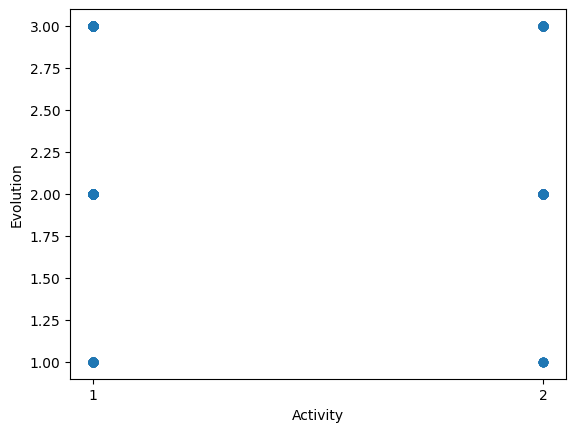

In [154]:
#This needs to be a scatter
ActivityVsEvolution = pd.DataFrame({'x':df["activity"], 'y':df["evolution"]})

plt.scatter(ActivityVsEvolution['x'], ActivityVsEvolution['y'])
plt.xticks([1,2])
plt.xlabel("Activity")
plt.ylabel("Evolution")
plt.show()

# Z Class vs C, M, and X

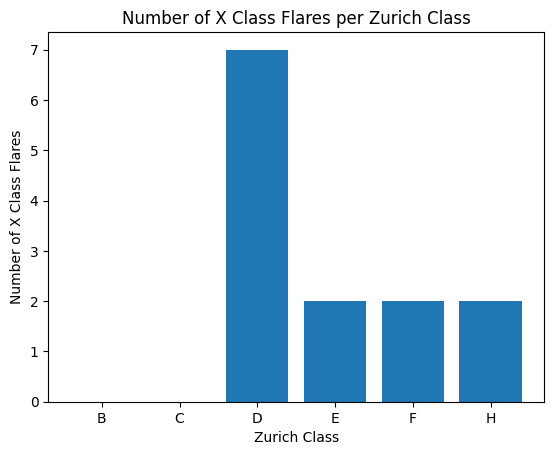

In [60]:
z_v_x_class_counts = df.groupby("zurich_class")["x_class_flares"].sum()
plt.bar(z_v_x_class_counts.index, z_v_x_class_counts.values)
plt.title("Number of X Class Flares per Zurich Class")
plt.xlabel("Zurich Class")
plt.ylabel("Number of X Class Flares")
plt.show()

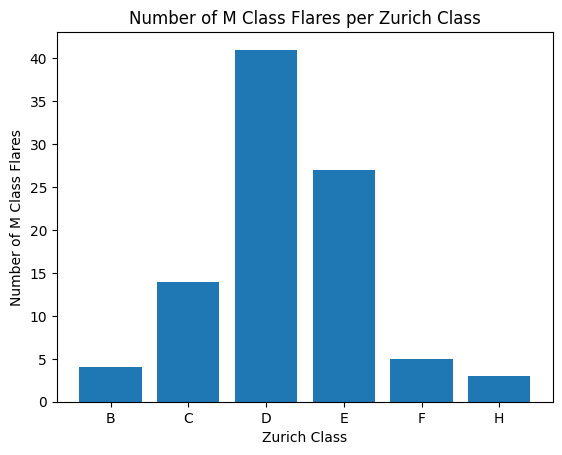

In [61]:
z_v_m_class_counts = df.groupby("zurich_class")["m_class_flares"].sum()
plt.bar(z_v_m_class_counts.index, z_v_m_class_counts.values)
plt.title("Number of M Class Flares per Zurich Class")
plt.xlabel("Zurich Class")
plt.ylabel("Number of M Class Flares")
plt.show()

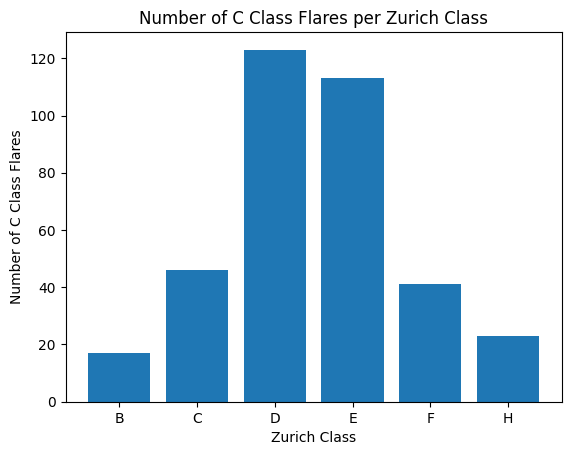

In [62]:
z_v_c_class_counts = df.groupby("zurich_class")["c_class_flares"].sum()
plt.bar(z_v_c_class_counts.index, z_v_c_class_counts.values)
plt.title("Number of C Class Flares per Zurich Class")
plt.xlabel("Zurich Class")
plt.ylabel("Number of C Class Flares")
plt.show()

The D class flares have what seem to be the most flares overall. I'm going to make a graph of how many of each they all have.

In [64]:
df_flares_only = df[["zurich_class", "c_class_flares", "m_class_flares", "x_class_flares"]]

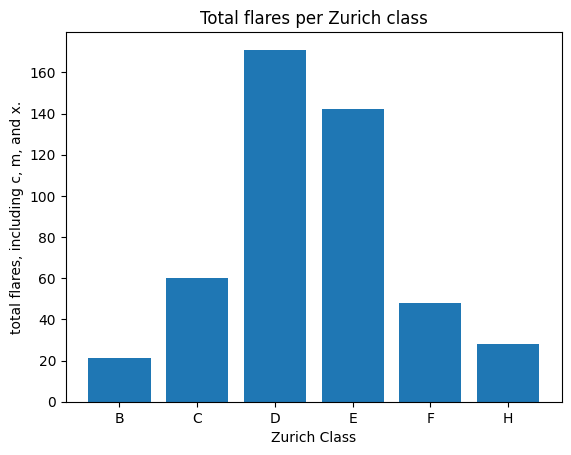

In [170]:
total = df_total_flares.groupby("zurich_class")["total_flares"].sum()

plt.bar(total.index, total.values)

plt.title("Total flares per Zurich class")
plt.xlabel("Zurich Class")
plt.ylabel("total flares, including c, m, and x.")
plt.show()

# Z Class Vs Historic Complexities

The majority of historic complexity occured when it was an F class sunspot. There were the least amount of f class flares, so this data stands out.

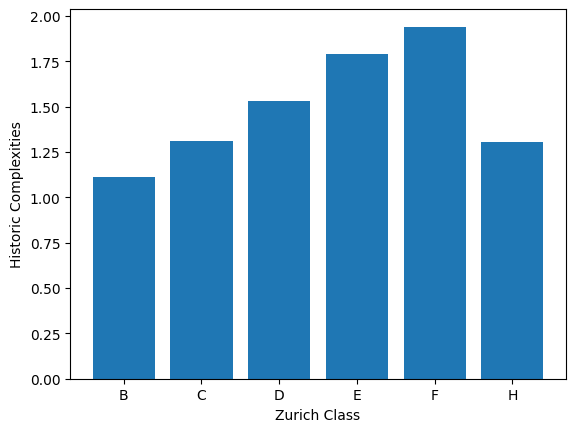

In [171]:
z_v_historic_complexities = df.groupby("zurich_class")["historically_complex"].mean()
plt.bar(z_v_historic_complexities.index, z_v_historic_complexities.values)

plt.xlabel("Zurich Class")
plt.ylabel("Historic Complexities")
plt.show()

# New Data Frame

In [159]:
dfx = df[df["x_class_flares"] > 0]
dfx

,zurich_class,largest_spot_size,spot_distribution,activity,evolution,prev_24hr_flare_activity,historically_complex,became_complex_this_pass,area,area_largest_spot,c_class_flares,m_class_flares,x_class_flares
30,D,A,O,1,3,1,1,2,1,2,1,0,1
62,D,K,C,2,3,3,2,2,1,2,1,2,1
75,D,K,I,1,3,1,2,2,1,2,0,2,1
106,H,S,X,1,1,1,2,2,1,2,0,0,1
257,D,K,C,1,3,1,2,2,1,2,0,1,1
259,H,A,X,1,3,1,2,2,1,2,0,1,1
310,D,K,C,2,2,3,2,2,2,2,1,0,1
546,F,A,I,2,2,1,2,2,1,1,1,0,1
1273,F,K,C,1,2,1,2,2,2,1,0,1,1
1283,D,K,C,2,3,1,2,2,2,1,1,3,2


In [4]:
total_flares = df["c_class_flares"] + df["m_class_flares"] + df["x_class_flares"]

In [5]:
df_total_flares = df
df_total_flares['total_flares'] = total_flares
df_total_flares

,zurich_class,largest_spot_size,spot_distribution,activity,evolution,prev_24hr_flare_activity,historically_complex,became_complex_this_pass,area,area_largest_spot,c_class_flares,m_class_flares,x_class_flares,total_flares
0,C,S,O,1,2,1,1,2,1,2,0,0,0,0
1,D,S,O,1,3,1,1,2,1,2,0,0,0,0
2,C,S,O,1,3,1,1,2,1,1,0,0,0,0
3,D,S,O,1,3,1,1,2,1,2,0,0,0,0
4,D,A,O,1,3,1,1,2,1,2,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1384,H,S,X,1,2,1,1,1,1,1,0,0,0,0
1385,H,S,X,2,2,1,1,2,1,1,0,0,0,0
1386,C,S,O,1,2,1,2,2,1,1,0,0,0,0
1387,H,R,X,1,2,1,1,2,1,1,0,0,0,0


In [6]:
df

,zurich_class,largest_spot_size,spot_distribution,activity,evolution,prev_24hr_flare_activity,historically_complex,became_complex_this_pass,area,area_largest_spot,c_class_flares,m_class_flares,x_class_flares,total_flares
0,C,S,O,1,2,1,1,2,1,2,0,0,0,0
1,D,S,O,1,3,1,1,2,1,2,0,0,0,0
2,C,S,O,1,3,1,1,2,1,1,0,0,0,0
3,D,S,O,1,3,1,1,2,1,2,0,0,0,0
4,D,A,O,1,3,1,1,2,1,2,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1384,H,S,X,1,2,1,1,1,1,1,0,0,0,0
1385,H,S,X,2,2,1,1,2,1,1,0,0,0,0
1386,C,S,O,1,2,1,2,2,1,1,0,0,0,0
1387,H,R,X,1,2,1,1,2,1,1,0,0,0,0


Notes from Mentor Meeting today:

Dr. Wooten said to maybe make a heat map because it's hard to tell how many points are in one place.

cite data

Include C in the research question

make data more polished: only do possible values on x and y axes, etc

think about the real world when you're making your project

any graph should tell most of the story... audience should mostly get it, then you explain it, then they should easily get it.